1. Modify the above program to use criterion="entropy" instead of "gini".
2. Build a simple decision-support system for medical diagnosis using a decision tree.

In [5]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize the Decision Tree Classifier
# You can adjust hyperparameters like max_depth, criterion (gini or entropy)
dt_classifier = DecisionTreeClassifier(random_state=42,criterion='entropy')

# 4. Train the model
dt_classifier.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

Decision Tree Classifier Performance:
Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



Accuracy: 0.9298245614035088

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        43
           1       0.94      0.94      0.94        71

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



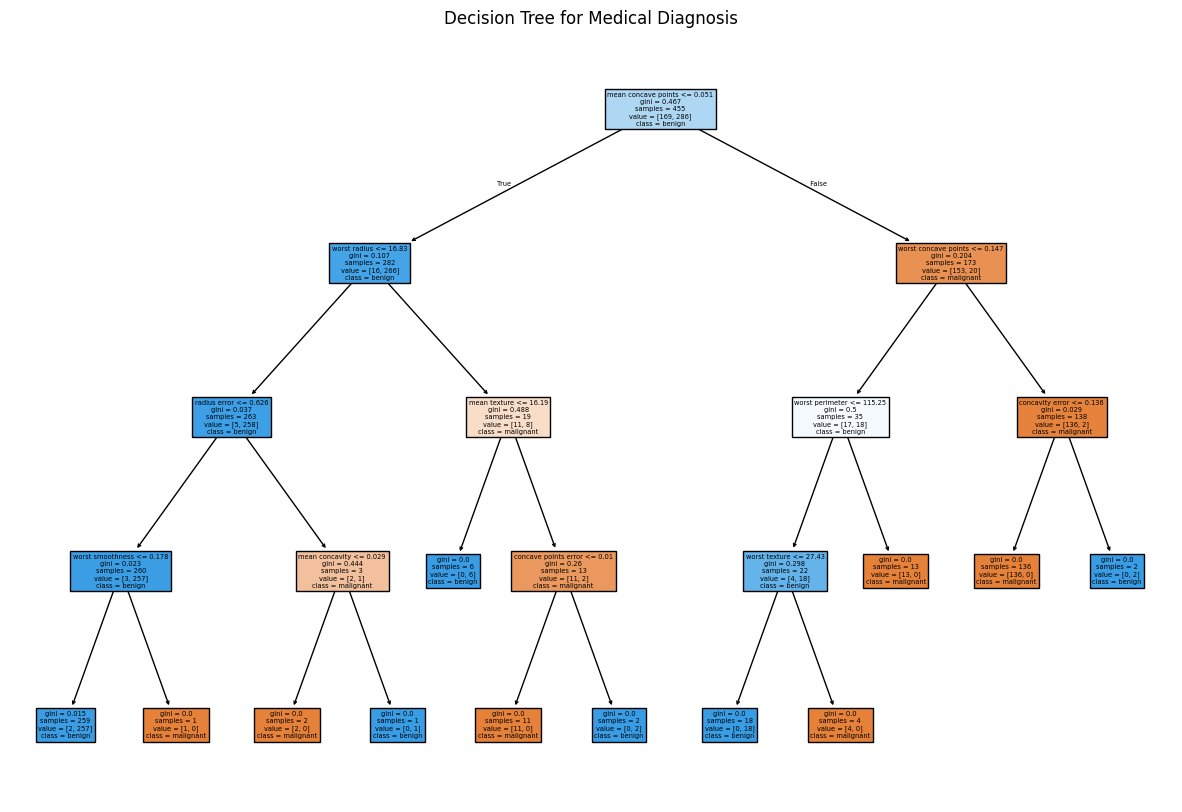

Diagnosis: Benign (No Cancer)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()
X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=4)  # limit depth for clarity
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree for Medical Diagnosis")
plt.show()

sample_patient = [X_test[0]]

prediction = model.predict(sample_patient)

if prediction[0] == 0:
    print("Diagnosis: Malignant (Cancer)")
else:
    print("Diagnosis: Benign (No Cancer)")